### import all the necesseary pacakges

In [1]:
import numpy as np
import pandas as pd
import os
from pyspatialml import Raster
#from osgeo import gdal
import rasterio
from rasterio.merge import merge

import matplotlib as mpl 
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import jaccard_score
from sklearn.metrics import ConfusionMatrixDisplay

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling

### Set the directory

os.chdir(r"D:\Research\Flood Susceptibility\KOSHI_FSM\rasters")

In [2]:
os.chdir(r"D:\Research\Flood Susceptibility\KOSHI_FSM\rasters")

### Reprojects and aligns a raster

In [3]:
def reproject_align(infile, reference_file, outfile):
    with rasterio.open(reference_file) as ref:
        dst_crs = ref.crs
        dst_transform = ref.transform
        dst_width = ref.width
        dst_height = ref.height

    with rasterio.open(infile) as src:
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': dst_transform,
            'width': dst_width,
            'height': dst_height
        })

        with rasterio.open(outfile, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=dst_transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest)

In [4]:
original_files = [
    'NDVI.tif', 
    'DEM.tif', 
    'NDBI.tif',  
    'Precipitation.tif',  
    'Aspect.tif', 
    'DD.tif',
    'DR.tif',  
    'TWI.tif', 
    'Slope.tif',
    'TPI.tif',
    'TRI.tif',
    'GFI.tif',
    'Curvature.tif',

    
]


# Use the first raster as the reference
reference_file = original_files[0]

# Align all rasters and save with '_aligned' suffix
aligned_files = []
for infile in original_files:
    if infile == reference_file:
        aligned_files.append(infile)  # already aligned
    else:
        aligned_name = infile.replace('.tif', '_align2.tif')
        reproject_align(infile, reference_file, aligned_name)
        aligned_files.append(aligned_name)

# Create raster stack
stack = Raster(aligned_files)
print("Raster stack created with layers:", stack.names)

Raster stack created with layers: dict_keys(['NDVI', 'DEM_align2', 'NDBI_align2', 'Precipitation_align2', 'Aspect_align2', 'DD_align2', 'DR_align2', 'TWI_align2', 'Slope_align2', 'TPI_align2', 'TRI_align2', 'GFI_align2', 'Curvature_align2'])


c:\Users\kkhan16\.conda\envs\fsm\Lib\site-packages\matplotlib\colors.py:2294: RuntimeWarning: overflow encountered in divide
  resdat /= (vmax - vmin)
c:\Users\kkhan16\.conda\envs\fsm\Lib\site-packages\matplotlib\colors.py:777: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


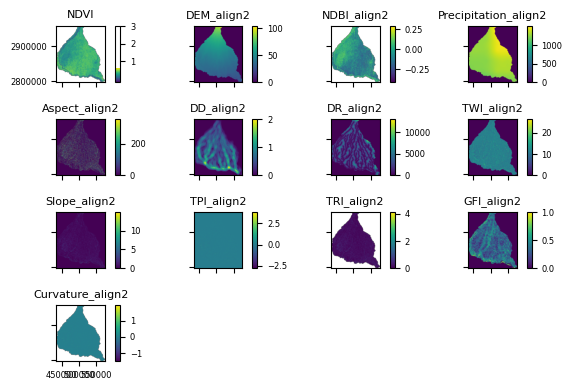

In [5]:
axs = stack.plot(figsize=(6, 4))
ax = axs.flatten()[0]
im = ax.images
im[0].colorbar.set_ticks([1,2,3])
ax = axs.flatten()[0]
ax.tick_params(axis='x', labelrotation=65)

plt.tight_layout()
plt.show()

### Random Points 


(12000, 4)
   Class      POINT_X       POINT_Y                        geometry
0      1  546597.2830  2.872914e+06  POINT (546597.283 2872914.095)
1      1  481472.0927  2.870132e+06  POINT (481472.093 2870131.984)
2      1  507188.5544  2.948765e+06  POINT (507188.554 2948765.035)
3      1  561286.8837  2.822079e+06  POINT (561286.884 2822079.286)
4      1  486074.6345  2.873911e+06  POINT (486074.634 2873911.199)


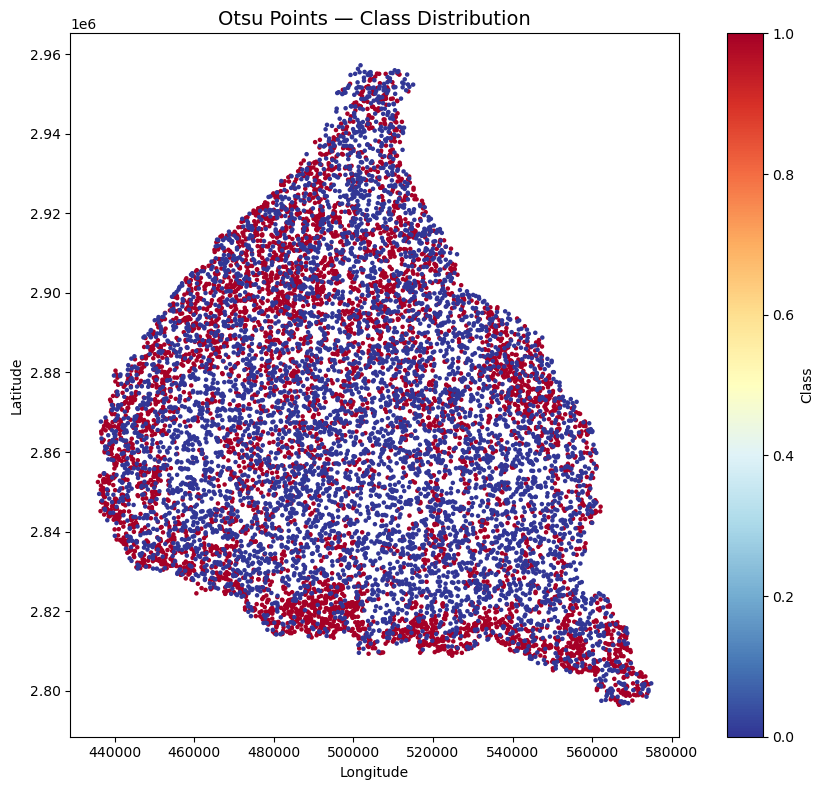

In [17]:
points = gpd.read_file(r"D:\Research\Flood Susceptibility\Data\otsu.shp")
points = points.rename(columns={'CID': 'Class'})
print(points.shape)
print(points.head())

fig, ax = plt.subplots(figsize=(10, 8))
points.plot(ax=ax, column='Class', cmap='RdYlBu_r', markersize=5, legend=True, legend_kwds={'label': 'Class'})
ax.set_title('Otsu Points — Class Distribution', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()






In [18]:
# Add a unique index to `points` if not already there
if 'index' not in points.columns:
    points['index'] = points.index

# Ensure points are in the same CRS as the rasters
with rasterio.open(original_files[0]) as src:
    raster_crs = src.crs
    points = points.to_crs(raster_crs)

# DataFrame to store extracted data
extracted_data = pd.DataFrame()

# Loop through each raster and extract values at point locations
for raster_path in original_files:
    with rasterio.open(raster_path) as src:
        # Extract raster values at each point
        values = [next(src.sample([(point.x, point.y)]))[0] for point in points.geometry]
        
        # Add the values to the DataFrame
        raster_name = raster_path.split('.')[0]
        extracted_data[raster_name] = values

# Add an index or unique identifier to `extracted_data` for merging
extracted_data['geometry_idx'] = points.index

# Merge additional information from the points DataFrame
# Here, we're merging based on the unique index/identifier
extracted_data = extracted_data.merge(
    right=points[['index', 'Class']],
    left_on='geometry_idx',
    right_on='index',
    how='left'  # Use 'left' to keep all rows from `extracted_data`
)

# Show the first 5 rows of the merged data
print("Training Data (first 5 rows):")
print(extracted_data.head(5))

Training Data (first 5 rows):
       NDVI  DEM      NDBI  Precipitation      Aspect        DD           DR  \
0  0.309316   42 -0.162072    1403.056641   -1.000000  0.793366  1256.968262   
1  0.325987   44 -0.082921    1248.638428  153.434952  0.941228   794.976501   
2  0.389105   87 -0.181518    1433.413940   -1.000000  0.232405  5332.864746   
3  0.200484   29  0.072804    1283.976318   45.000000  0.063306  5621.333008   
4  0.153178   46  0.068798    1261.183838   -1.000000  0.491752  1777.621582   

         TWI     Slope       TPI       TRI       GFI  Curvature  geometry_idx  \
0  13.377994  0.000000  0.000000  0.000000  0.200000  -0.000000             0   
1  11.271793  1.862383  0.444443  0.496904  0.384615   0.232219             1   
2  11.896389  0.000000  0.000000  0.000000  0.300000  -0.000000             2   
3  10.980099  0.618234 -0.111111  0.314270  0.250000  -0.000000             3   
4  13.619156  0.000000  0.000000  0.000000  0.125000  -0.000000             4   

  

### Preliminary Dataset for Model Training 

In [19]:
sample_data = extracted_data.drop(columns=['geometry_idx', 'index'])
sample_data

,NDVI,DEM,NDBI,Precipitation,Aspect,DD,DR,TWI,Slope,TPI,TRI,GFI,Curvature,Class
0,0.309316,42,-0.162072,1403.056641,-1.000000,0.793366,1256.968262,13.377994,0.000000,0.000000,0.000000,0.200000,-0.000000,1
1,0.325987,44,-0.082921,1248.638428,153.434952,0.941228,794.976501,11.271793,1.862383,0.444443,0.496904,0.384615,0.232219,1
2,0.389105,87,-0.181518,1433.413940,-1.000000,0.232405,5332.864746,11.896389,0.000000,0.000000,0.000000,0.300000,-0.000000,1
3,0.200484,29,0.072804,1283.976318,45.000000,0.063306,5621.333008,10.980099,0.618234,-0.111111,0.314270,0.250000,-0.000000,1
4,0.153178,46,0.068798,1261.183838,-1.000000,0.491752,1777.621582,13.619156,0.000000,0.000000,0.000000,0.125000,-0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.092035,37,0.067302,1254.716309,-1.000000,0.299120,4497.066406,10.980099,0.000000,0.000000,0.000000,0.363636,-0.000000,0
11996,0.416400,36,-0.176991,1226.292603,135.000000,1.129126,1777.621582,14.822762,0.550911,-0.111111,0.314270,0.454545,-0.000000,0
11997,0.115530,42,0.095636,1333.269653,-1.000000,1.076254,1686.399902,13.582788,0.000000,0.000000,0.000000,0.642857,-0.000000,0
11998,0.292691,45,0.043105,1397.702026,45.000000,0.137469,5536.370605,9.472090,1.807091,-0.333332,0.471405,0.363636,-0.232219,0


### Multicollinearity Analysis

Scaled data shape: (12000, 13)
           NDVI       DEM      NDBI  Precipitation    Aspect        DD  \
count  12000.00  12000.00  12000.00       12000.00  12000.00  12000.00   
mean       0.00     -0.00      0.00          -0.00     -0.00     -0.00   
std        1.00      1.00      1.00           1.00      1.00      1.00   
min       -3.50     -3.45     -2.70         -15.86     -0.55     -1.95   
25%       -0.79     -0.72     -0.96          -0.70     -0.55     -0.68   
50%        0.15     -0.19     -0.03          -0.29     -0.55     -0.19   
75%        0.90      0.57      0.93           0.51      0.20      0.57   
max        2.47      4.21      9.18           2.42      3.15      4.47   

             DR       TWI     Slope       TPI       TRI       GFI  Curvature  
count  12000.00  12000.00  12000.00  12000.00  12000.00  12000.00   12000.00  
mean      -0.00      0.00     -0.00      0.00     -0.00      0.00      -0.00  
std        1.00      1.00      1.00      1.00      1.00      1.00

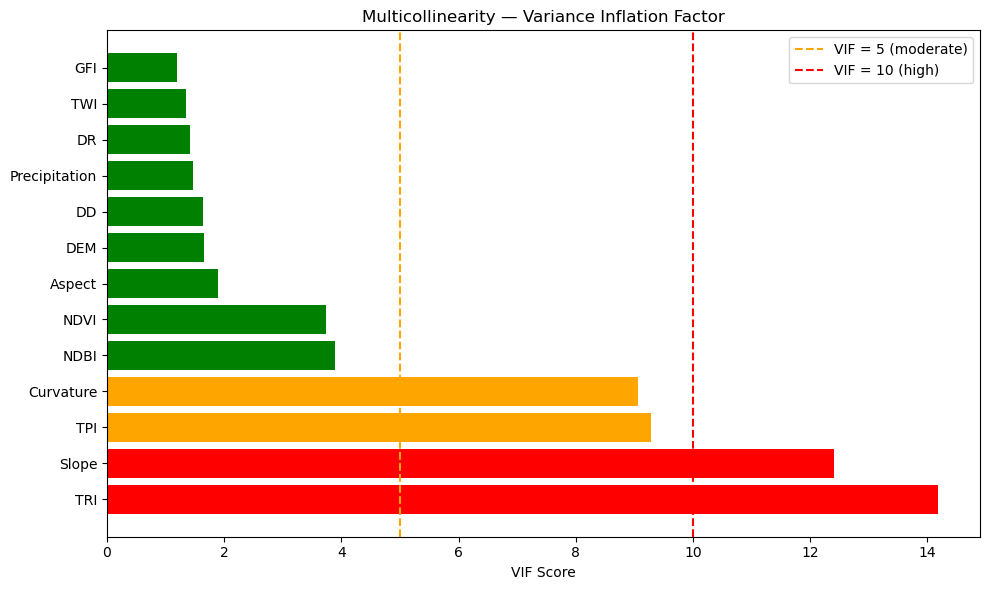

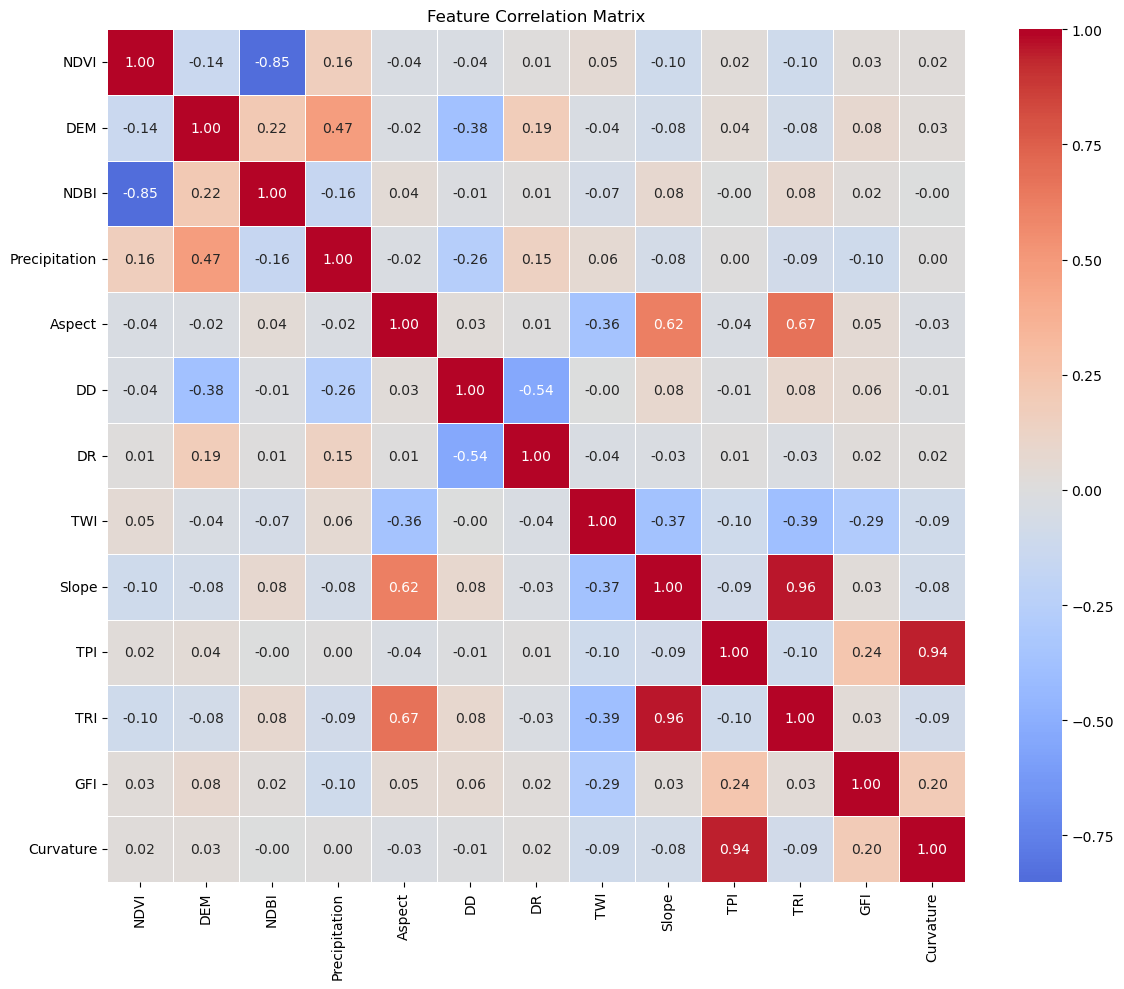

In [22]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Drop non-feature columns
exclude_cols = ['Class', 'label', 'CID', 'geometry', 'longitude', 'latitude']
feature_cols = [c for c in sample_data.columns if c not in exclude_cols]

X = sample_data[feature_cols].dropna()

# ── Standard Scaling ──────────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
print("Scaled data shape:", X_scaled.shape)
print(X_scaled.describe().round(2))

# ── Multicollinearity — VIF ───────────────────────────────────
vif_data = pd.DataFrame()
vif_data['Feature'] = feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF Results:")
print(vif_data.to_string(index=False))

# ── VIF Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if v > 10 else 'orange' if v > 5 else 'green' for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
ax.axvline(x=5,  color='orange', linestyle='--', label='VIF = 5 (moderate)')
ax.axvline(x=10, color='red',    linestyle='--', label='VIF = 10 (high)')
ax.set_xlabel('VIF Score')
ax.set_title('Multicollinearity — Variance Inflation Factor')
ax.legend()
plt.tight_layout()
plt.show()

# ── Correlation Heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(X_scaled.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


### Feature Reduction 

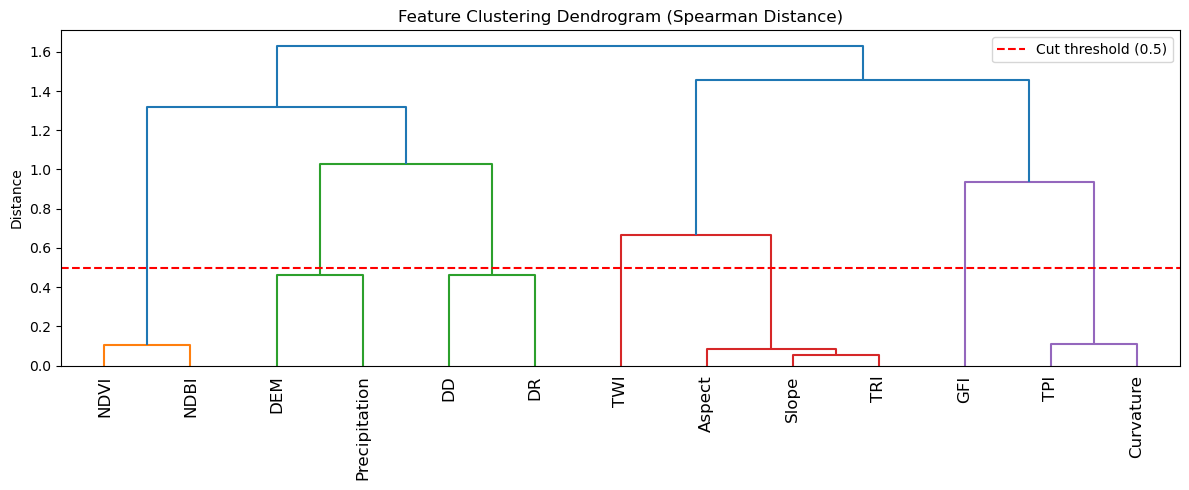

Separated Precipitation into its own cluster (ID 8)

Feature Clusters:
      Feature  Cluster
         NDVI        1
         NDBI        1
          DEM        2
Precipitation        2
           DD        3
           DR        3
       Aspect        4
        Slope        4
          TRI        4
          TWI        5
          TPI        6
    Curvature        6
          GFI        7
Force-added DEM to selected features

Selected features (8): ['NDVI', 'Precipitation', 'DR', 'Aspect', 'TWI', 'Curvature', 'GFI', 'DEM']
Dropped: ['NDBI', 'DD', 'Slope', 'TPI', 'TRI']

VIF after reduction:
      Feature      VIF
          DEM 1.442686
Precipitation 1.439302
          TWI 1.267896
          GFI 1.167053
       Aspect 1.163344
         NDVI 1.107791
    Curvature 1.049365
           DR 1.043806


In [29]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

# ── 1. Spearman Correlation Distance ─────────────────────────
corr, _ = spearmanr(X_scaled)
corr_df = pd.DataFrame(corr, columns=feature_cols, index=feature_cols)

dissimilarity = 1 - np.abs(corr_df.values)
dissimilarity = (dissimilarity + dissimilarity.T) / 2
np.fill_diagonal(dissimilarity, 0)

# ── 2. Hierarchical Clustering + Dendrogram ───────────────────
linkage_matrix = hierarchy.linkage(squareform(dissimilarity), method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
hierarchy.dendrogram(linkage_matrix, labels=feature_cols, ax=ax, leaf_rotation=90)
ax.axhline(y=0.5, color='red', linestyle='--', label='Cut threshold (0.5)')
ax.set_title('Feature Clustering Dendrogram (Spearman Distance)')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.show()

# ── 3. Retain one feature per cluster (lowest VIF) ───────────
threshold = 0.5
cluster_ids = hierarchy.fcluster(linkage_matrix, threshold, criterion='distance')

cluster_df = pd.DataFrame({'Feature': feature_cols, 'Cluster': cluster_ids})

# ── Force DEM and Precipitation into separate clusters ────────
dem_cluster = cluster_df.loc[cluster_df['Feature'] == 'DEM', 'Cluster'].values[0]
pre_cluster = cluster_df.loc[cluster_df['Feature'] == 'Precipitation', 'Cluster'].values[0]

if dem_cluster == pre_cluster:
    # Assign Precipitation its own new cluster ID
    new_cluster_id = cluster_df['Cluster'].max() + 1
    cluster_df.loc[cluster_df['Feature'] == 'Precipitation_align2', 'Cluster'] = new_cluster_id
    print(f"Separated Precipitation into its own cluster (ID {new_cluster_id})")

print("\nFeature Clusters:")
print(cluster_df.sort_values('Cluster').to_string(index=False))

# ── 4. Select best feature per cluster ───────────────────────
selected_features = []
for cid in sorted(cluster_df['Cluster'].unique()):
    cluster_feats = cluster_df[cluster_df['Cluster'] == cid]['Feature'].tolist()
    cluster_vif = vif_data[vif_data['Feature'].isin(cluster_feats)]
    best = cluster_vif.loc[cluster_vif['VIF'].idxmin(), 'Feature']
    selected_features.append(best)

# Ensure both DEM and Precipitation are always included
for must_keep in ['DEM', 'Precipitation']:
    if must_keep not in selected_features:
        selected_features.append(must_keep)
        print(f"Force-added {must_keep} to selected features")

print(f"\nSelected features ({len(selected_features)}): {selected_features}")
print(f"Dropped: {[f for f in feature_cols if f not in selected_features]}")

X_reduced = X_scaled[selected_features]

# ── 5. VIF recheck ────────────────────────────────────────────
vif_reduced = pd.DataFrame({
    'Feature': selected_features,
    'VIF': [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVIF after reduction:")
print(vif_reduced.to_string(index=False))


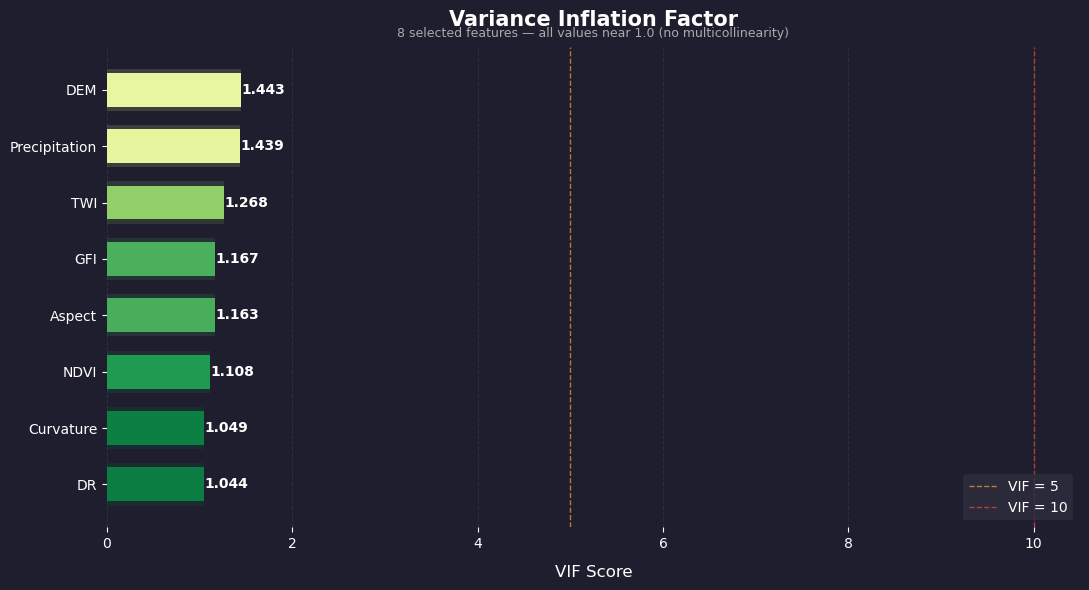

In [31]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Gradient-style colors based on VIF value
cmap = plt.cm.RdYlGn_r
norm = plt.Normalize(vmin=1.0, vmax=2.0)
colors = [cmap(norm(v)) for v in vif_reduced['VIF']]

bars = ax.barh(vif_reduced['Feature'], vif_reduced['VIF'],
               color=colors, edgecolor='none', height=0.6)

# Subtle glow effect
for bar, val, color in zip(bars, vif_reduced['VIF'], colors):
    ax.barh(bar.get_y() + bar.get_height()/2, bar.get_width(),
            height=0.75, left=0, color=color, alpha=0.15)
    # Value labels
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', color='white', fontsize=10, fontweight='bold')

# Threshold lines
ax.axvline(x=5,  color='#f5a623', linestyle='--', linewidth=1, alpha=0.7, label='VIF = 5')
ax.axvline(x=10, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.7, label='VIF = 10')

# Styling
ax.set_xlabel('VIF Score', color='white', fontsize=12, labelpad=10)
ax.set_title('Variance Inflation Factor', color='white', fontsize=15,
             fontweight='bold', pad=15)
ax.tick_params(colors='white', labelsize=10)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.xaxis.grid(True, color='white', alpha=0.07, linestyle='--')
ax.set_axisbelow(True)
ax.invert_yaxis()
ax.legend(facecolor='#2e2e3e', edgecolor='none', labelcolor='white',
          fontsize=10, loc='lower right')

# Subtitle
ax.text(0.5, 1.02, '8 selected features — all values near 1.0 (no multicollinearity)',
        transform=ax.transAxes, ha='center', color='#aaaaaa', fontsize=9)

plt.tight_layout()
plt.show()


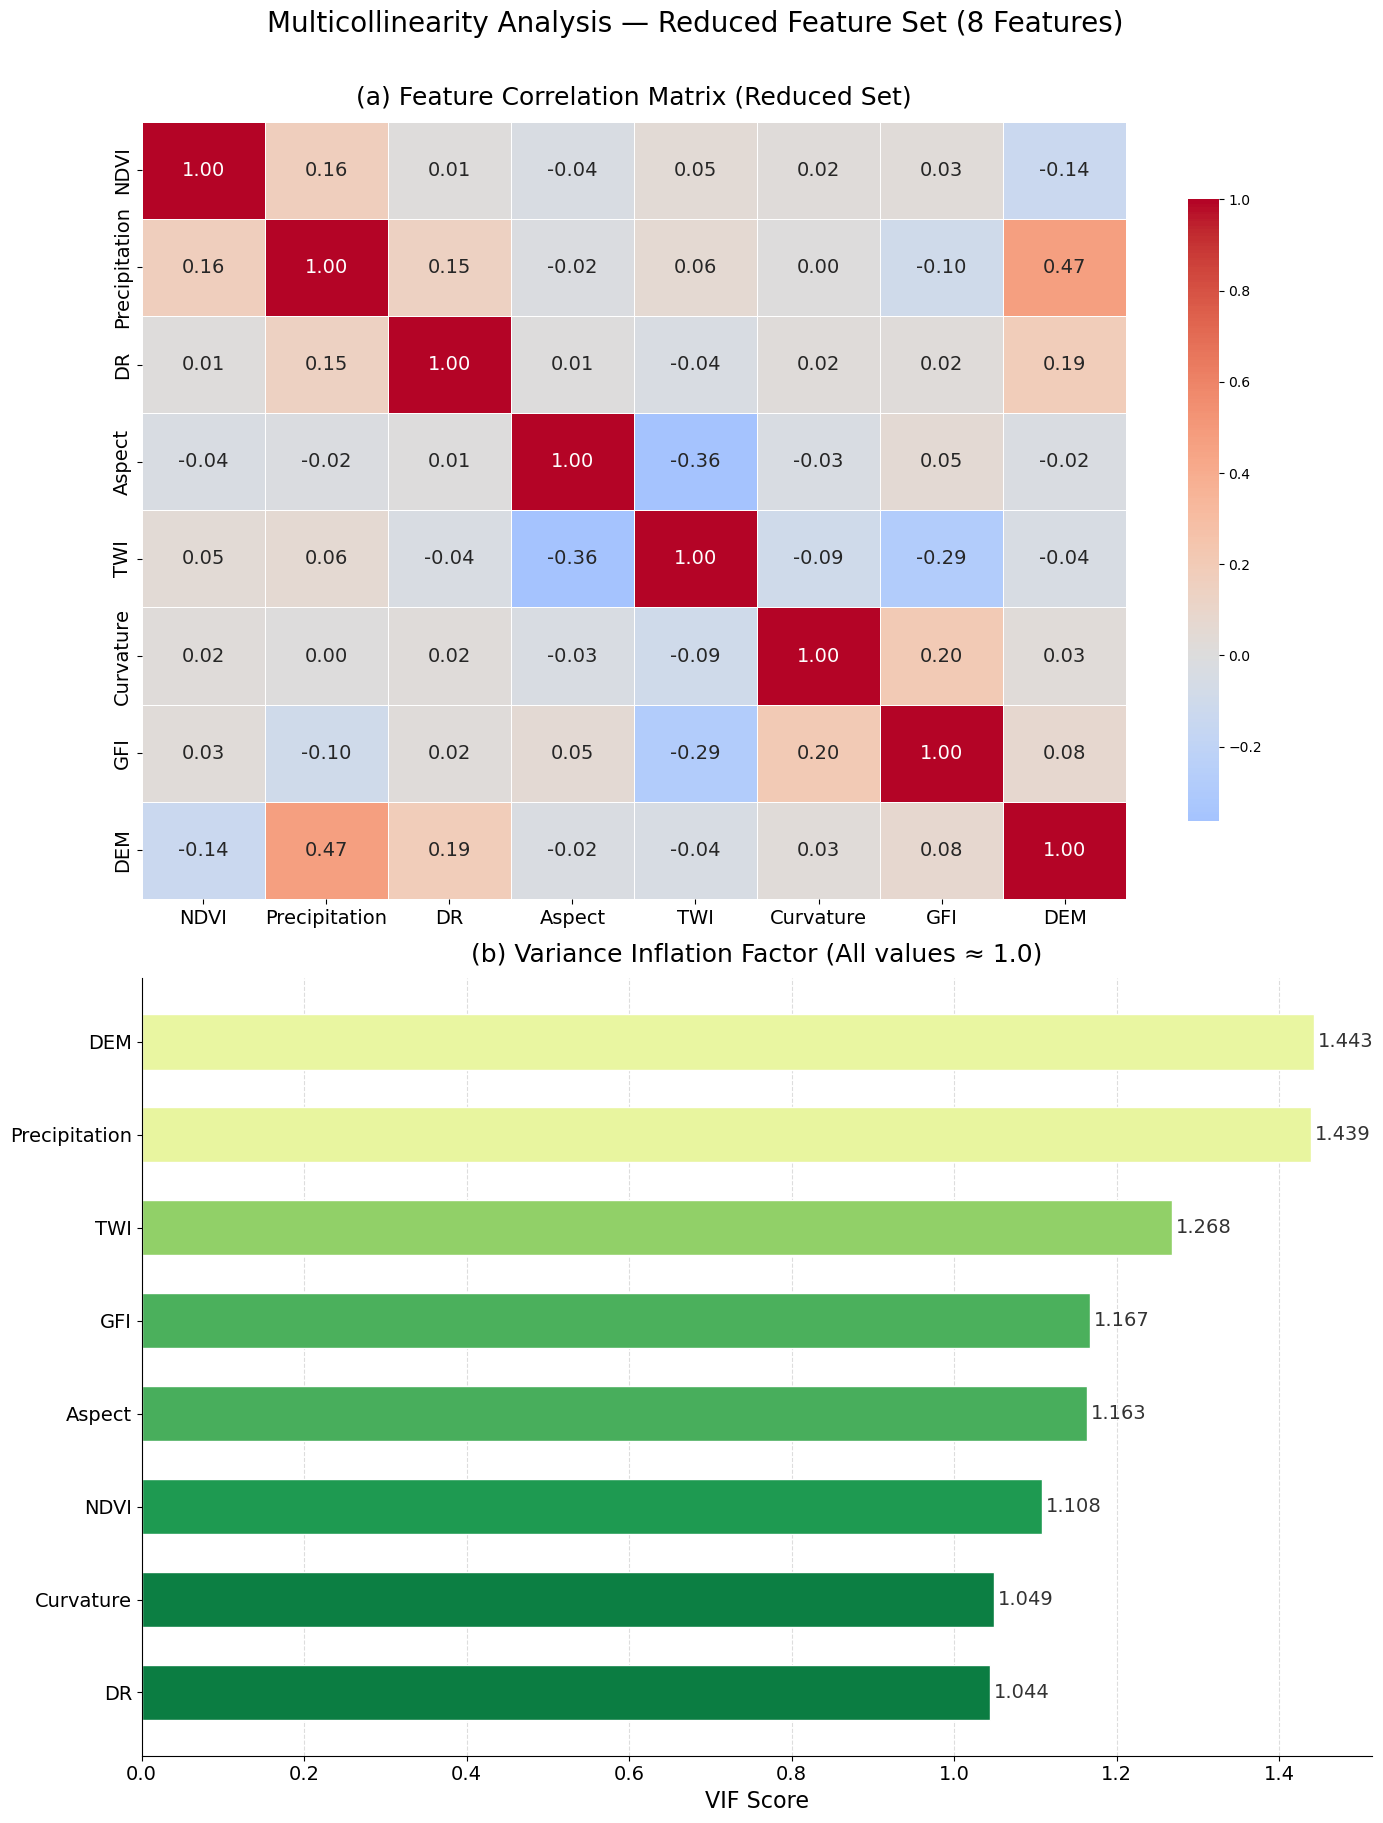

In [76]:
fig, axes = plt.subplots(2, 1, figsize=(14, 18))

# ── (a) Correlation Heatmap ───────────────────────────────────
ax1 = axes[0]
sns.heatmap(X_reduced.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax1, linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 14})
ax1.set_title('(a) Feature Correlation Matrix (Reduced Set)',
              fontsize=18, pad=12)
ax1.tick_params(labelsize=14)

# ── (b) VIF Bar Chart ─────────────────────────────────────────
ax2 = axes[1]
cmap = plt.cm.RdYlGn_r
norm = plt.Normalize(vmin=1.0, vmax=2.0)
colors = [cmap(norm(v)) for v in vif_reduced['VIF']]

bars = ax2.barh(vif_reduced['Feature'], vif_reduced['VIF'],
                color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, vif_reduced['VIF']):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=14, color='#333333')

ax2.set_xlabel('VIF Score', fontsize=16)
ax2.set_title('(b) Variance Inflation Factor (All values ≈ 1.0)',
              fontsize=18, pad=12)
ax2.tick_params(labelsize=14)
ax2.spines[['top', 'right']].set_visible(False)
ax2.xaxis.grid(True, color='#dddddd', linestyle='--')
ax2.set_axisbelow(True)
ax2.invert_yaxis()

plt.suptitle('Multicollinearity Analysis — Reduced Feature Set (8 Features)',
             fontsize=20, y=1.01)
plt.tight_layout()
plt.savefig(r'D:\Research\Flood Susceptibility\Data\Rasters\output\multicollinearity_reduced.png',
            dpi=600, bbox_inches='tight')
plt.show()


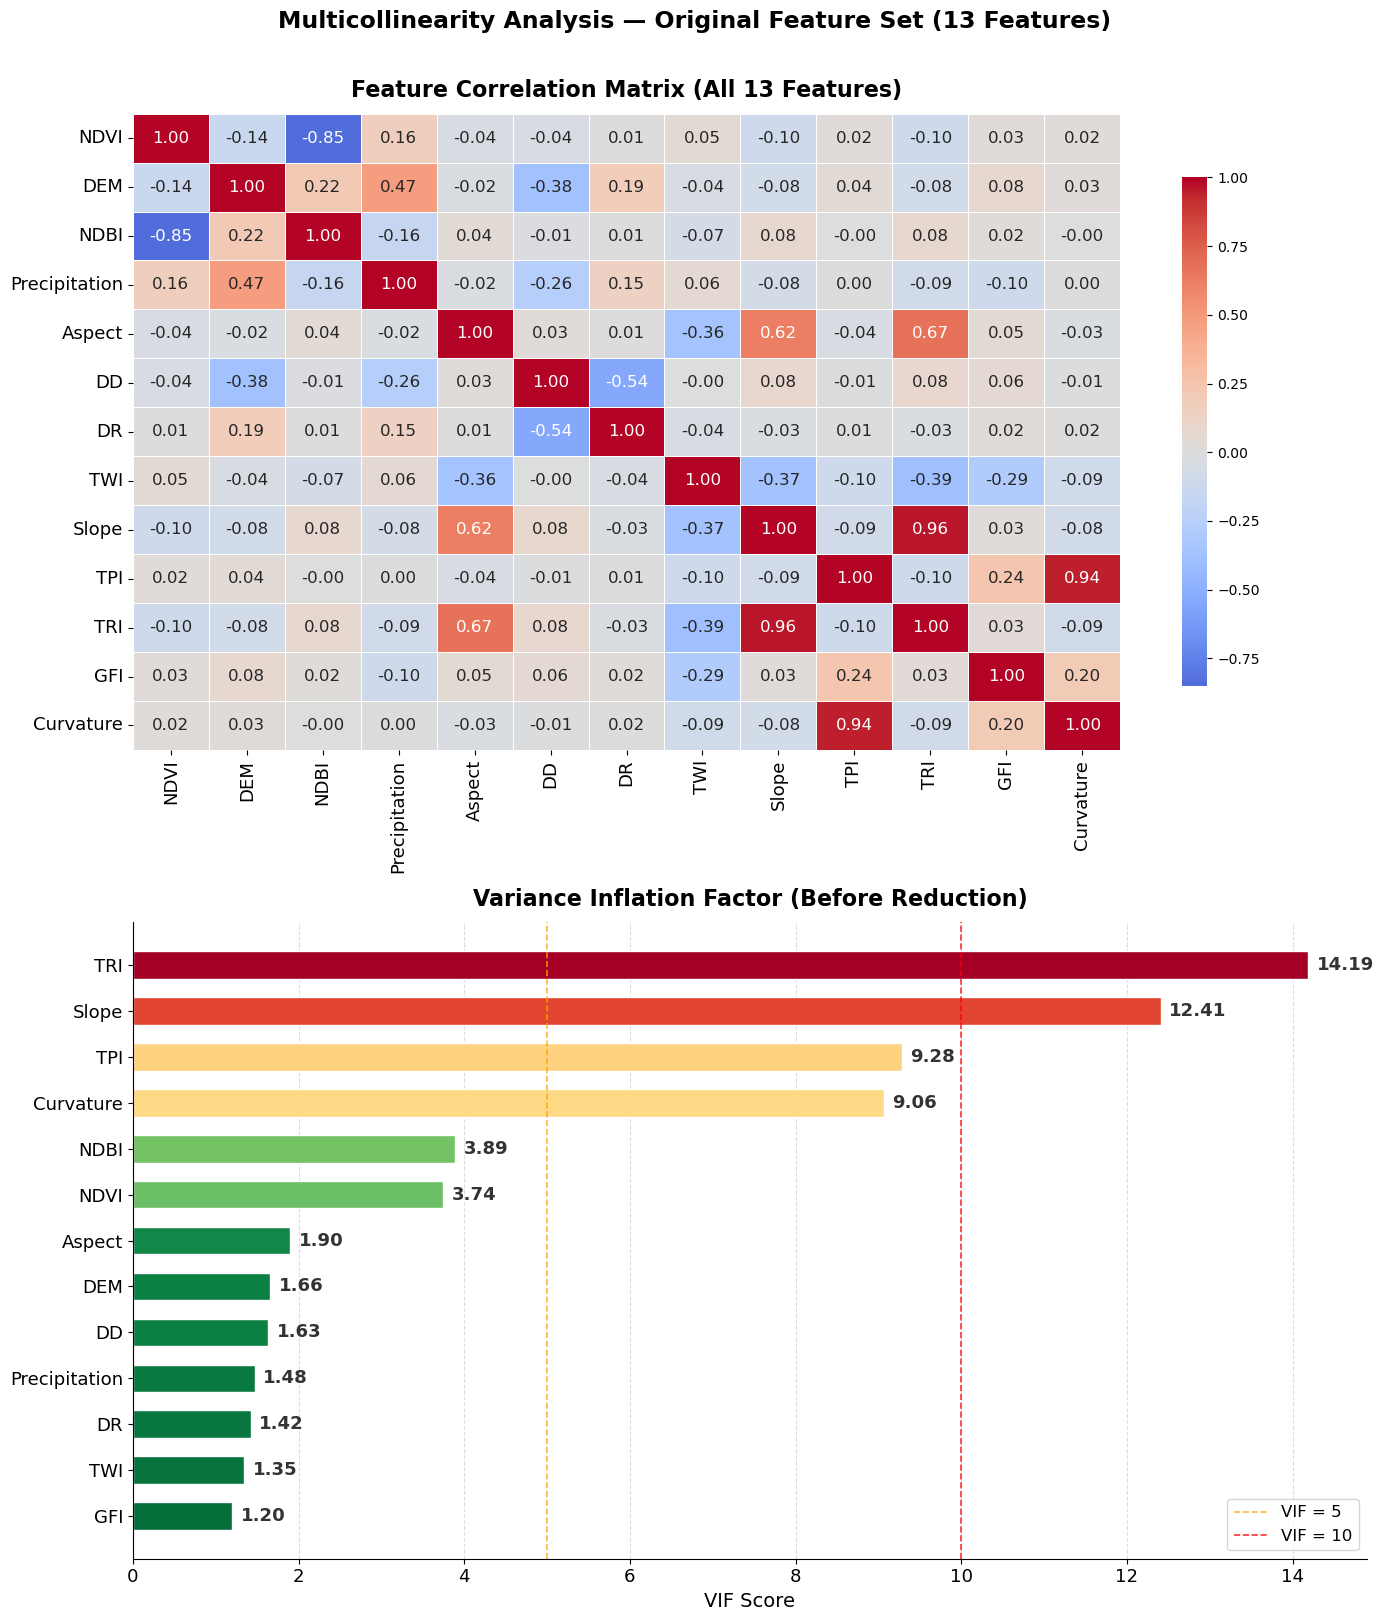

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# ── Top: Correlation Heatmap ──────────────────────────────────
ax1 = axes[0]
sns.heatmap(X_scaled.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax1, linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 12})
ax1.set_title('Feature Correlation Matrix (All 13 Features)', fontsize=16, fontweight='bold', pad=12)
ax1.tick_params(labelsize=13)

# ── Bottom: VIF Bar Chart ─────────────────────────────────────
ax2 = axes[1]
vif_sorted = vif_data.sort_values('VIF', ascending=False)
cmap = plt.cm.RdYlGn_r
norm = plt.Normalize(vmin=1.0, vmax=vif_sorted['VIF'].max())
colors = [cmap(norm(v)) for v in vif_sorted['VIF']]

bars = ax2.barh(vif_sorted['Feature'], vif_sorted['VIF'],
                color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, vif_sorted['VIF']):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=13, fontweight='bold', color='#333333')

ax2.axvline(x=5,  color='orange', linestyle='--', linewidth=1.2, alpha=0.8, label='VIF = 5')
ax2.axvline(x=10, color='red',    linestyle='--', linewidth=1.2, alpha=0.8, label='VIF = 10')
ax2.set_xlabel('VIF Score', fontsize=14)
ax2.set_title('Variance Inflation Factor (Before Reduction)', fontsize=16, fontweight='bold', pad=12)
ax2.tick_params(labelsize=13)
ax2.spines[['top', 'right']].set_visible(False)
ax2.xaxis.grid(True, color='#dddddd', linestyle='--')
ax2.set_axisbelow(True)
ax2.invert_yaxis()
ax2.legend(fontsize=12)

plt.suptitle('Multicollinearity Analysis — Original Feature Set (13 Features)',
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


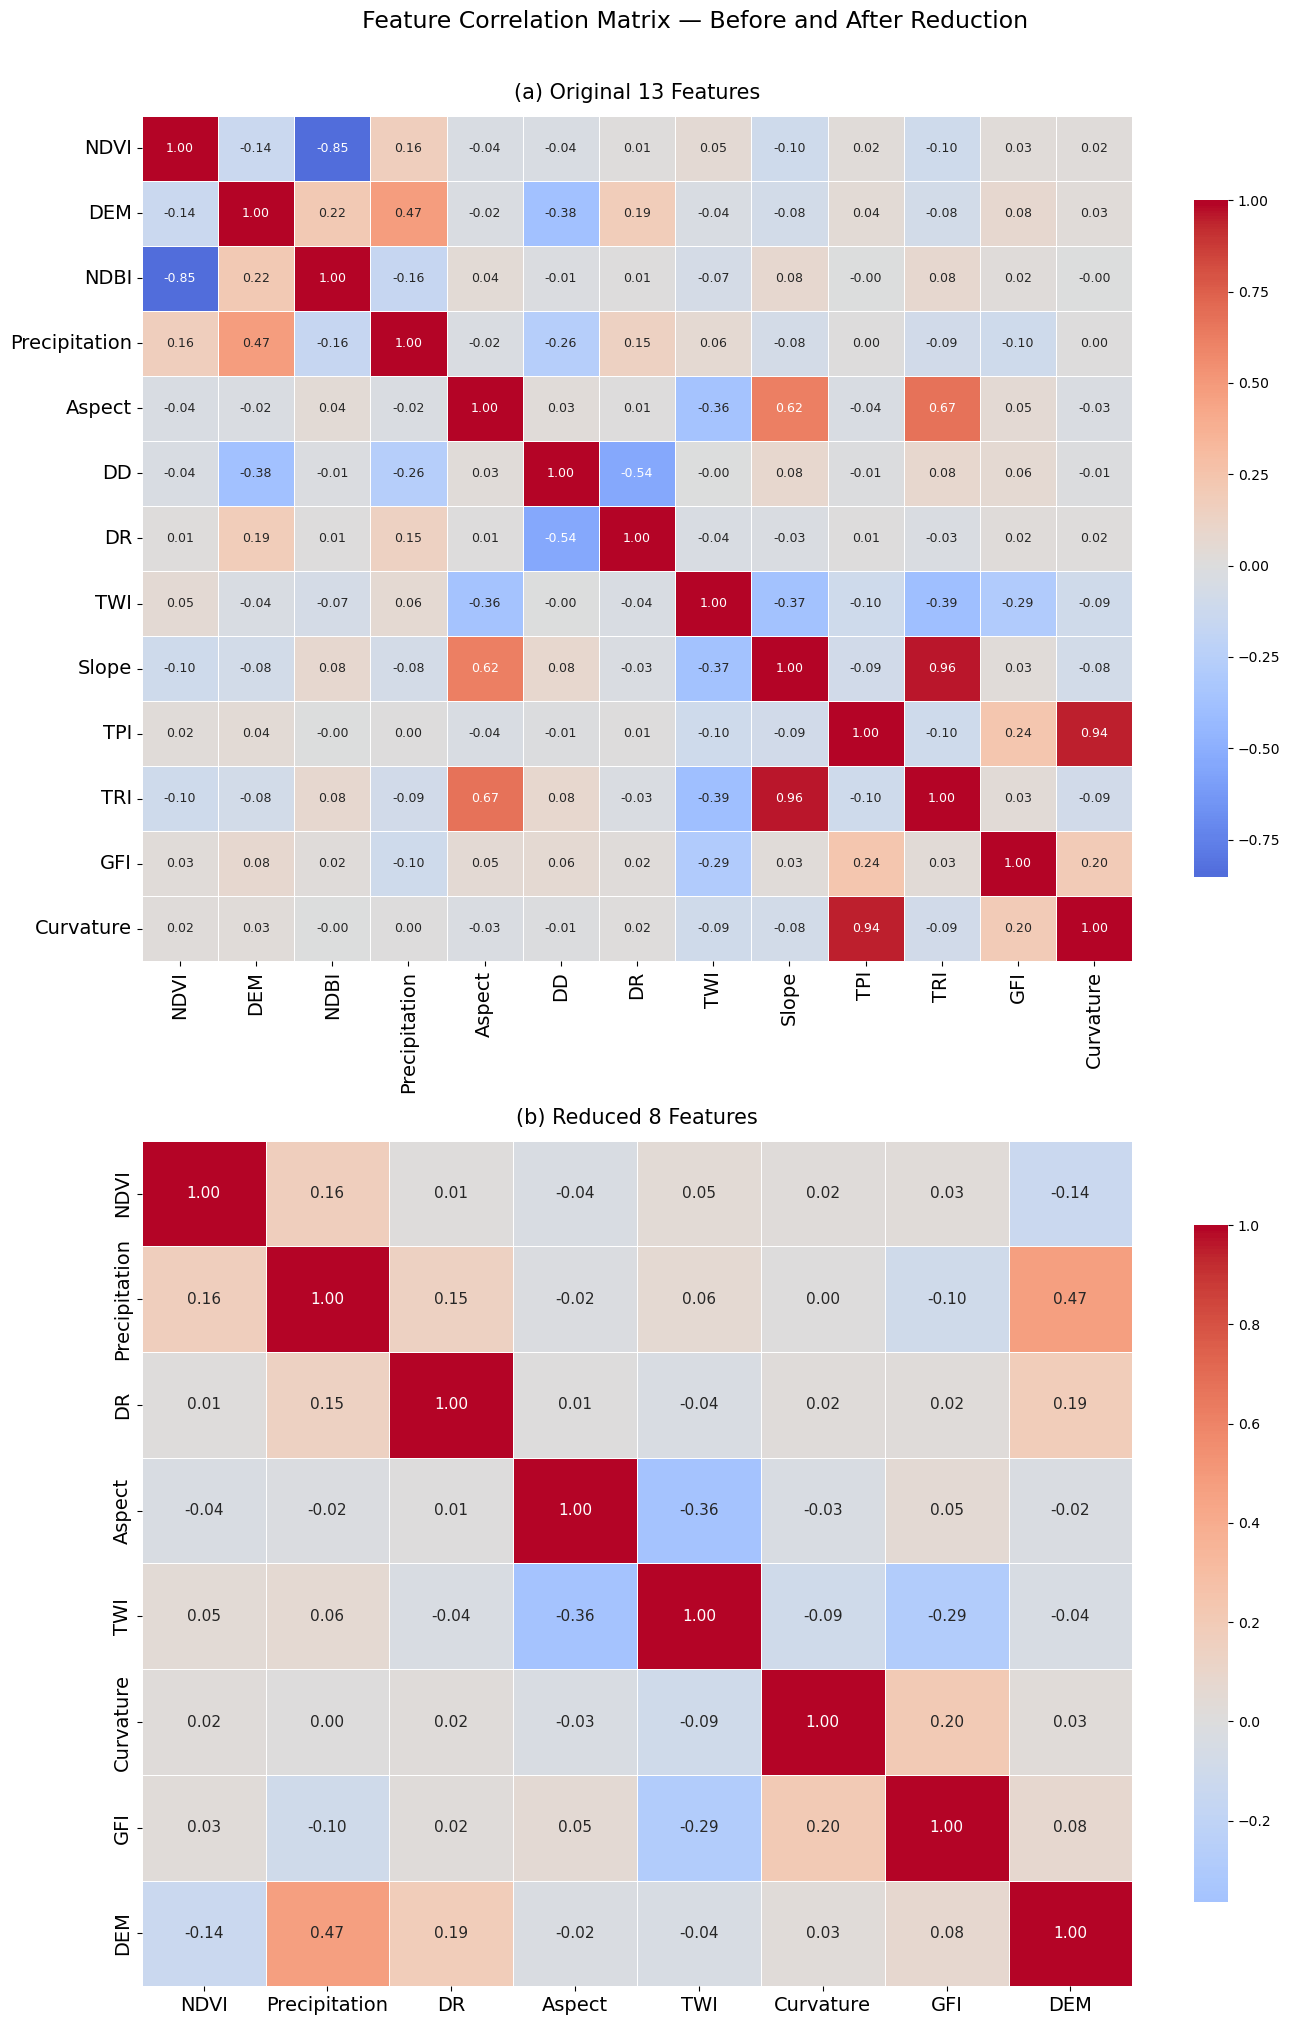

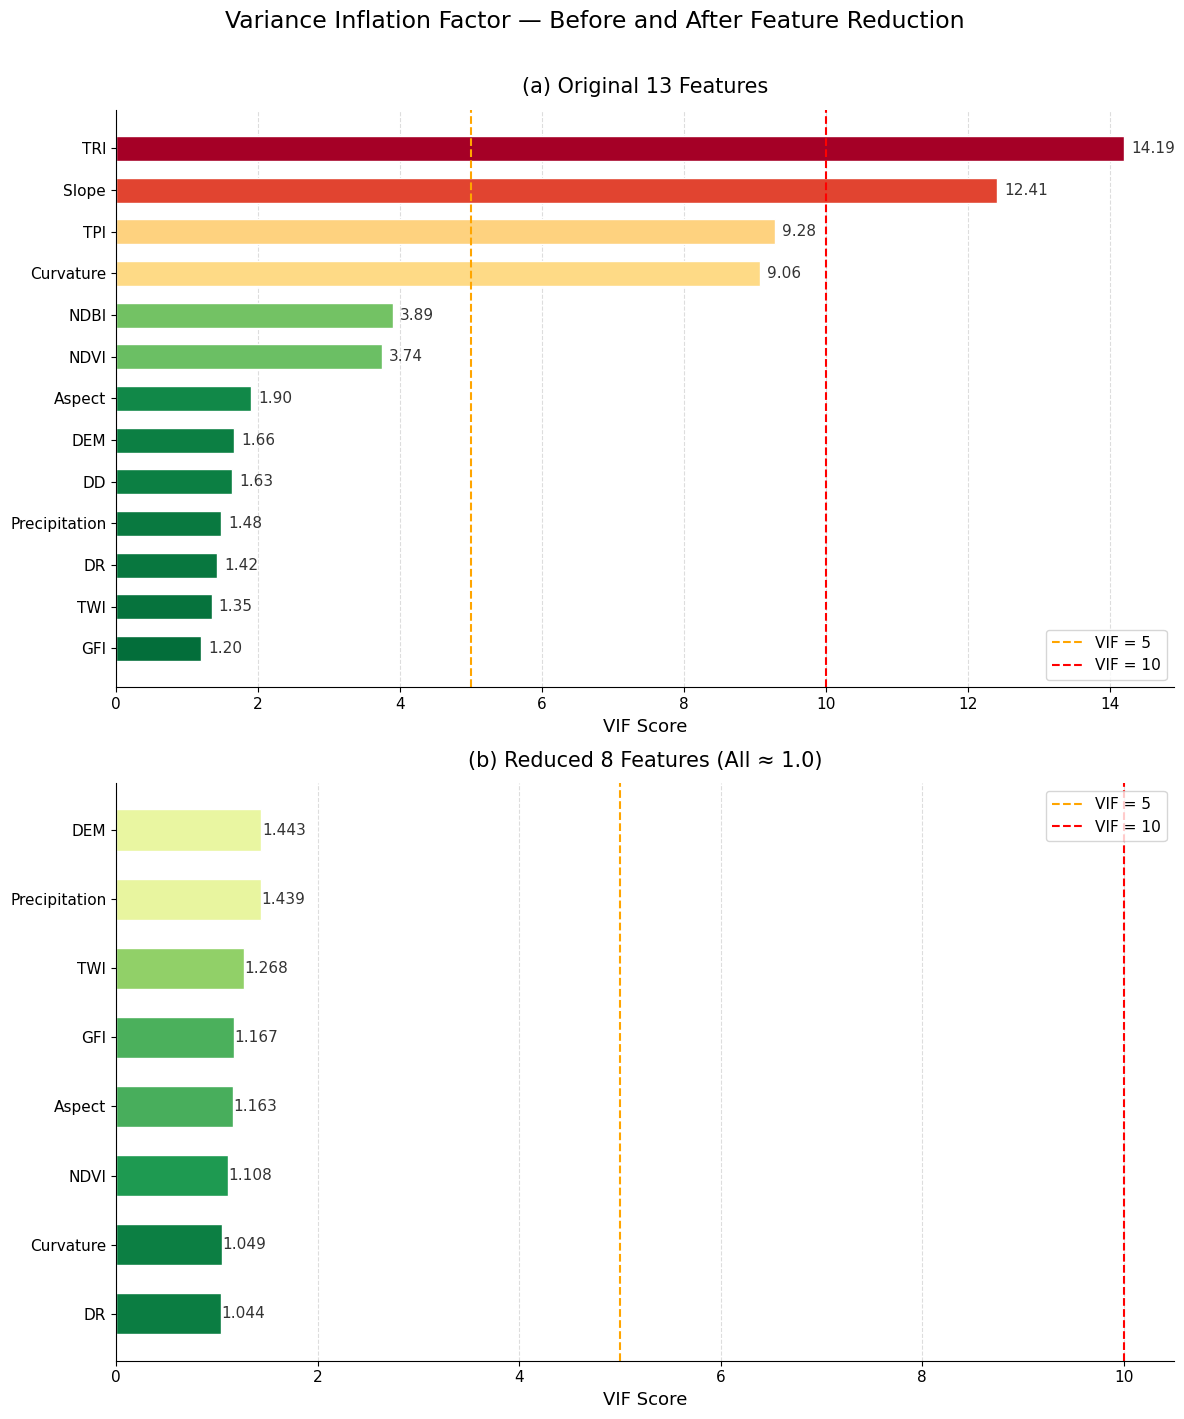

In [ ]:
# ═══════════════════════════════════════════════════════════════
# Figure 1 — Correlation Matrices (Before & After)
# ═══════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 1, figsize=(14, 20))

sns.heatmap(X_scaled.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
axes[0].set_title('(a) Original 13 Features', fontsize=15, pad=12)
axes[0].tick_params(labelsize=14)

sns.heatmap(X_reduced.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 11})
axes[1].set_title('(b) Reduced 8 Features', fontsize=15, pad=12)
axes[1].tick_params(labelsize=14)

plt.suptitle('Feature Correlation Matrix — Before and After Reduction',
             fontsize=17, y=1.01)
plt.tight_layout()
plt.savefig(r'D:\Research\Flood Susceptibility\Data\Rasters\output\correlation_before_after.png',
            dpi=600, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════
# Figure 2 — VIF (Before & After)
# ═══════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(2, 1, figsize=(12, 14))
cmap_vif = plt.cm.RdYlGn_r

# ── (a) Before ────────────────────────────────────────────────
ax1 = axes[0]
vif_sorted    = vif_data.sort_values('VIF', ascending=False)
norm_before   = plt.Normalize(vmin=1.0, vmax=vif_sorted['VIF'].max())
colors_before = [cmap_vif(norm_before(v)) for v in vif_sorted['VIF']]

bars = ax1.barh(vif_sorted['Feature'], vif_sorted['VIF'],
                color=colors_before, edgecolor='white', height=0.6)
for bar, val in zip(bars, vif_sorted['VIF']):
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=11, color='#333333')
ax1.axvline(x=5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5')
ax1.axvline(x=10, color='red',    linestyle='--', linewidth=1.5, label='VIF = 10')
ax1.set_xlabel('VIF Score', fontsize=13)
ax1.set_title('(a) Original 13 Features', fontsize=15, pad=12)
ax1.tick_params(labelsize=11)
ax1.spines[['top', 'right']].set_visible(False)
ax1.xaxis.grid(True, color='#dddddd', linestyle='--')
ax1.set_axisbelow(True)
ax1.invert_yaxis()
ax1.legend(fontsize=11)

# ── (b) After ─────────────────────────────────────────────────
ax2 = axes[1]
norm_after   = plt.Normalize(vmin=1.0, vmax=2.0)
colors_after = [cmap_vif(norm_after(v)) for v in vif_reduced['VIF']]

bars = ax2.barh(vif_reduced['Feature'], vif_reduced['VIF'],
                color=colors_after, edgecolor='white', height=0.6)
for bar, val in zip(bars, vif_reduced['VIF']):
    ax2.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=11, color='#333333')
ax2.axvline(x=5,  color='orange', linestyle='--', linewidth=1.5, label='VIF = 5')
ax2.axvline(x=10, color='red',    linestyle='--', linewidth=1.5, label='VIF = 10')
ax2.set_xlabel('VIF Score', fontsize=13)
ax2.set_title('(b) Reduced 8 Features (All ≈ 1.0)', fontsize=15, pad=12)
ax2.tick_params(labelsize=11)
ax2.spines[['top', 'right']].set_visible(False)
ax2.xaxis.grid(True, color='#dddddd', linestyle='--')
ax2.set_axisbelow(True)
ax2.invert_yaxis()
ax2.legend(fontsize=11)

plt.suptitle('Variance Inflation Factor — Before and After Feature Reduction',
             fontsize=17, y=1.01)
plt.tight_layout()
plt.savefig(r'D:\Research\Flood Susceptibility\Data\Rasters\output\vif_before_after.png',
            dpi=600, bbox_inches='tight')
plt.show()


### Train Test Split

In [39]:
X = sample_data[selected_features]
y = sample_data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"\nClass distribution — Train:\n{y_train.value_counts()}")
print(f"\nClass distribution — Test:\n{y_test.value_counts()}")


Train size : 8400 samples
Test size  : 3600 samples

Class distribution — Train:
Class
0    4200
1    4200
Name: count, dtype: int64

Class distribution — Test:
Class
1    1800
0    1800
Name: count, dtype: int64
